<a href="https://colab.research.google.com/github/SattuSupCodes/PythonJournal/blob/main/kddcup99.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
from sklearn.datasets import fetch_kddcup99

In [37]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder


In [25]:
X, y = fetch_kddcup99(return_X_y=True, subset = 'http', percent10=True, random_state=42, as_frame = True)

In [29]:
mod = KNeighborsClassifier()
pipe = Pipeline([
    ('scale' , StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=1))
])
pipe.get_params()


{'memory': None,
 'steps': [('scale', StandardScaler()),
  ('model', KNeighborsClassifier(n_neighbors=1))],
 'transform_input': None,
 'verbose': False,
 'scale': StandardScaler(),
 'model': KNeighborsClassifier(n_neighbors=1),
 'scale__copy': True,
 'scale__with_mean': True,
 'scale__with_std': True,
 'model__algorithm': 'auto',
 'model__leaf_size': 30,
 'model__metric': 'minkowski',
 'model__metric_params': None,
 'model__n_jobs': None,
 'model__n_neighbors': 1,
 'model__p': 2,
 'model__weights': 'uniform'}

In [38]:
y_decoded = y.apply(lambda x: x.decode('utf-8'))
le = LabelEncoder()
y_encoded = le.fit_transform(y_decoded)

pipe.fit(X, y_encoded)

Pipeline(steps=[('scale', StandardScaler()),
                ('model', KNeighborsClassifier(n_neighbors=1))])

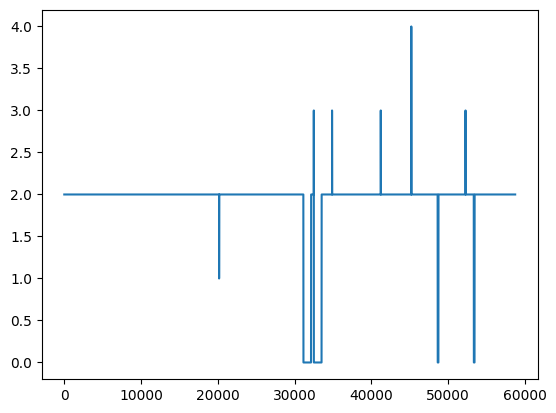

In [35]:
pred = pipe.predict(X)
plt.plot(pred)

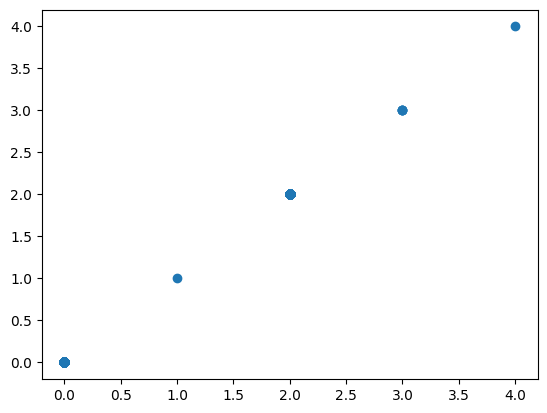

In [36]:
plt.scatter(y_encoded, pred)

# every time I think I know something I realize I don’t